In [1]:
import torch
from torch import nn
from torch import optim
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [2]:
import math

In [3]:
import plotly.graph_objects as go
import numpy as np


In [4]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [5]:
def generate_sphere(num_points, radius=1.0, add_noise=False, noise_std=0.05, device='cpu'):

    # phi (azimut) in [0, 2pi)
    phi = torch.rand(num_points, device=device)*2*math.pi
    
    # cos(theta) in [-1, 1] per evitare l'addensamento ai poli!!
    costheta = (torch.rand(num_points, device=device)*2) - 1
    theta = torch.acos(costheta)
    
    # 2. Trasformazione in coordinate cartesiane
    x = radius * torch.sin(theta) * torch.cos(phi)
    y = radius * torch.sin(theta) * torch.sin(phi)
    z = radius * torch.cos(theta)
    
    #(theta, phi)
    angles = torch.stack((theta, phi), dim=1)
    #(x, y, z)
    cartesian = torch.stack((x, y, z), dim=1)
    
    if add_noise:
        cartesian += torch.randn_like(cartesian) * noise_std
        
    return angles, cartesian
#nota, così di default i dati sono su cpu, poi nel training li sposto!

In [6]:
N_points = 10000
X_angles, Y_cartesian = generate_sphere(N_points, radius=1.0)

print(f"Shape tensore angoli (Input): {X_angles.shape}")
print(f"Shape tensore cartesiano (Target): {Y_cartesian.shape}")

Shape tensore angoli (Input): torch.Size([10000, 2])
Shape tensore cartesiano (Target): torch.Size([10000, 3])


(nota che possiamo anche vedere come va al variare del batch size!!)

In [7]:
batch_size = 100 #ha senso usare così tanti minibatches? sono tanti? 
dataset = torch.utils.data.TensorDataset(Y_cartesian, X_angles)
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [int(0.8 * len(dataset)), int(0.2 * len(dataset))])
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=True)

In [8]:
dataset

In [9]:
print(train_loader.dataset[0])

(tensor([-0.8771, -0.3088, -0.3679]), tensor([1.9475, 3.4801]))


# The models

Now the model. we can to both with "**tied weights**" and **not tied** to see who performs better:
then we can take the winner (which I expect  to be the one who doesn't share the parameters) and we can go deep.



# model 1

In [60]:
in_dim = 3
out_dim = 2
hidden_dim = 100
#forse così impara una f.ne non lineare di 2 variabili(vediamo)
class Autoencoder(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), #0
            nn.LeakyReLU(),
            nn.Linear(hidden_dim, hidden_dim), #1
            nn.LeakyReLU(),
            nn.Linear(hidden_dim, out_dim), #2
            nn.LeakyReLU(), 
        )
        self.decoder = nn.Sequential(
            nn.Linear(out_dim, hidden_dim), #0
            nn.LeakyReLU(),
            nn.Linear(hidden_dim, hidden_dim), #1
            nn.LeakyReLU(),
            nn.Linear(hidden_dim, in_dim), #2 #voglio la RelU dopo questo layer?
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

model_1 = Autoencoder(in_dim, hidden_dim, out_dim).to(device)
#con sigmoide come va? tanh?
#servono così tanti neuroni? 

In [61]:
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model_1.parameters(), lr=0.5e-2, weight_decay=1e-5)

In [62]:
num_epochs = 100
model_1.train()
for epoch in range(num_epochs):

    loss_epoch = 0.0

    for x, _ in train_loader:

        x = x.to(device) #in teoria le y non servono no?

        x_pred = model_1(x)
        loss = loss_fn(x_pred, x)
        #train 
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_epoch += loss.item() #item() per prendere il valore scalare dal tensore
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch + 1}, Training Loss: {loss_epoch / len(train_loader):.5f}")


Epoch 5, Training Loss: 0.00349
Epoch 10, Training Loss: 0.00230
Epoch 15, Training Loss: 0.00200
Epoch 20, Training Loss: 0.00104
Epoch 25, Training Loss: 0.00111
Epoch 30, Training Loss: 0.00136
Epoch 35, Training Loss: 0.00024
Epoch 40, Training Loss: 0.00041
Epoch 45, Training Loss: 0.00150
Epoch 50, Training Loss: 0.00073
Epoch 55, Training Loss: 0.00155
Epoch 60, Training Loss: 0.00023
Epoch 65, Training Loss: 0.00202
Epoch 70, Training Loss: 0.00201
Epoch 75, Training Loss: 0.00071
Epoch 80, Training Loss: 0.00020
Epoch 85, Training Loss: 0.00062
Epoch 90, Training Loss: 0.00071
Epoch 95, Training Loss: 0.00046
Epoch 100, Training Loss: 0.00036


In [63]:
model_1.eval()
with torch.no_grad():
    for x, _ in test_loader:
        x = x.to(device)
        x_pred = model_1(x)
        loss = loss_fn(x_pred, x)
        print(f"Test Loss: {loss.item():.5f}")

Test Loss: 0.00047
Test Loss: 0.00081
Test Loss: 0.00021
Test Loss: 0.00030
Test Loss: 0.00025
Test Loss: 0.00042
Test Loss: 0.00026
Test Loss: 0.00051
Test Loss: 0.00028
Test Loss: 0.00040
Test Loss: 0.00026
Test Loss: 0.00045
Test Loss: 0.00021
Test Loss: 0.00034
Test Loss: 0.00030
Test Loss: 0.00024
Test Loss: 0.00081
Test Loss: 0.00057
Test Loss: 0.00048
Test Loss: 0.00051


In [64]:
model_1.eval()
encoder = model_1.encoder
decoder = model_1.decoder

# 2. Calcoliamo i confini effettivi dello spazio latente per sapere dove creare la griglia
with torch.no_grad():
    latents = encoder(Y_cartesian.to(device)).cpu().numpy()

z1_min, z1_max = latents[:, 0].min(), latents[:, 0].max()
z2_min, z2_max = latents[:, 1].min(), latents[:, 1].max()

# 3. Definiamo la densità della griglia (quanti "assi" vogliamo)
num_lines = 15       # Numero di linee per ogni asse coordinato
pts_per_line = 100   # Risoluzione di ogni linea per renderla fluida nel 3D

z1_values = np.linspace(z1_min, z1_max, num_lines)
z2_values = np.linspace(z2_min, z2_max, num_lines)

# 4. Inizializziamo la figura Plotly
fig = go.Figure()

# Nota: Mettiamo i punti originali grigi e trasparenti sullo sfondo per dare un riferimento visivo
x_orig = Y_cartesian[:, 0].cpu().numpy()
y_orig = Y_cartesian[:, 1].cpu().numpy()
z_orig = Y_cartesian[:, 2].cpu().numpy()

fig.add_trace(go.Scatter3d(
    x=x_orig, y=y_orig, z=z_orig,
    mode='markers',
    marker=dict(size=1.5, color='lightgray', opacity=0.15),
    name='Sfera di Riferimento'
))

# 5. Generiamo e decodifichiamo le linee degli assi latenti
with torch.no_grad():
    
    # --- ASSE 1: Linee a Z1 costante (varia Z2) -> Colore BLU ---
    for z1 in z1_values:
        line_2d = np.zeros((pts_per_line, 2))
        line_2d[:, 0] = z1
        line_2d[:, 1] = np.linspace(z2_min, z2_max, pts_per_line)
        
        # Passiamo la linea al decoder
        line_tensor = torch.tensor(line_2d, dtype=torch.float32).to(device)
        xyz = decoder(line_tensor).cpu().numpy()
        
        fig.add_trace(go.Scatter3d(
            x=xyz[:, 0], y=xyz[:, 1], z=xyz[:, 2],
            mode='lines',
            line=dict(color='rgba(0, 0, 255, 0.7)', width=2.5),
            showlegend=False
        ))

    # --- ASSE 2: Linee a Z2 costante (varia Z1) -> Colore ROSSO ---
    for z2 in z2_values:
        line_2d = np.zeros((pts_per_line, 2))
        line_2d[:, 0] = np.linspace(z1_min, z1_max, pts_per_line)
        line_2d[:, 1] = z2
        
        # Passiamo la linea al decoder
        line_tensor = torch.tensor(line_2d, dtype=torch.float32).to(device)
        xyz = decoder(line_tensor).cpu().numpy()
        
        fig.add_trace(go.Scatter3d(
            x=xyz[:, 0], y=xyz[:, 1], z=xyz[:, 2],
            mode='lines',
            line=dict(color='rgba(255, 0, 0, 0.7)', width=2.5), 
            showlegend=False
        ))

# 6. Configurazione finale del Layout per visualizzare una sfera perfetta
fig.update_layout(
    title="Assi di Coordinata dell'Autoencoder deformati sulla Sfera 3D",
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        aspectmode='cube' # Fondamentale per non distorcere la sfera in un uovo
    ),
    margin=dict(l=0, r=0, b=0, t=50)
)

fig.show()

# save model

In [65]:
from pathlib import Path

MODEL_PATH = Path("models")
#MODEL_PATH.mkdir(parents=True, exist_ok=True)
MODEL_NAME = "Sphere_autoencoder.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict 
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(), # only saving the state_dict() only saves the models learned parameters
           f=MODEL_SAVE_PATH) 

Saving model to: models\Sphere_autoencoder.pth


In [66]:
loaded_model = Autoencoder(in_dim, hidden_dim, out_dim).to(device)
# Load the state_dict of our saved model (this will update the new instance of our model with trained weights)
loaded_model.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [68]:
#encoder coordinates --> z_en
with torch.no_grad():
    encoder.to(device)
    encoder.eval()
    z_en = encoder(Y_cartesian.to(device))

# checking if the encoded data are angles (gone wrong)

In [15]:
z_en.shape

torch.Size([10000, 2])

In [16]:
#dataset
dataset_1 = torch.utils.data.TensorDataset(z_en, X_angles)
train_dataset_1, test_dataset_1 = torch.utils.data.random_split(dataset_1, [int(0.8 * len(dataset_1)), int(0.2 * len(dataset_1))])
train_loader_1 = torch.utils.data.DataLoader(train_dataset_1, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader_1 = torch.utils.data.DataLoader(test_dataset_1, batch_size=len(test_dataset_1), shuffle=False, drop_last=True)

In [17]:
class LinearRegressionModel(nn.Module): 
    def __init__(self):
        super().__init__() 
        self.param = nn.Linear(out_dim, out_dim)

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: 
        return self.param(x) 

model_0 = LinearRegressionModel().to(device)
    

In [18]:
dataset_1[:len(dataset_1)][0].shape

torch.Size([10000, 2])

In [19]:
loss_fn = nn.MSELoss()
optimizer_0 = optim.Adam(model_0.parameters(), lr=1e-2, weight_decay=1e-6)

In [ ]:
epochs = 10

train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    sum_loss = 0.0
    for x, y in train_loader_1:
        x = x.to(device)
        y = y.to(device)
        model_0.train()
        y_pred = model_0(x)
        loss = loss_fn(y_pred, y)
        sum_loss += loss.item()
        optimizer_0.zero_grad()
        loss.backward()
        optimizer_0.step()

    avg_loss = sum_loss / len(train_loader_1)
    with torch.no_grad(): 
      model_0.eval()
      for x, y in test_loader_1:
        test_features = x.to(device)
        test_labels = y.to(device)
      test_pred = model_0(test_features)
      test_loss = loss_fn(test_pred, test_labels)
      epoch_count.append(epoch)
      train_loss_values.append(avg_loss)
      test_loss_values.append(test_loss.detach().cpu().numpy())
      print(f"Epoch: {epoch} | MSE Train Loss: {avg_loss} | MSE Test Loss: {test_loss} ")

Epoch: 0 | MSE Train Loss: 4.086931055784225 | MSE Test Loss: 2.5509860515594482 
Epoch: 1 | MSE Train Loss: 2.1197632238268853 | MSE Test Loss: 1.9213542938232422 
Epoch: 2 | MSE Train Loss: 1.810364730656147 | MSE Test Loss: 1.7404215335845947 
Epoch: 3 | MSE Train Loss: 1.677709810435772 | MSE Test Loss: 1.6318426132202148 
Epoch: 4 | MSE Train Loss: 1.5938670635223389 | MSE Test Loss: 1.5609253644943237 
Epoch: 5 | MSE Train Loss: 1.5384213283658028 | MSE Test Loss: 1.51238214969635 
Epoch: 6 | MSE Train Loss: 1.5013457477092742 | MSE Test Loss: 1.4799244403839111 
Epoch: 7 | MSE Train Loss: 1.47755426466465 | MSE Test Loss: 1.4586290121078491 
Epoch: 8 | MSE Train Loss: 1.462637796998024 | MSE Test Loss: 1.4451409578323364 
Epoch: 9 | MSE Train Loss: 1.4541049674153328 | MSE Test Loss: 1.4374401569366455 


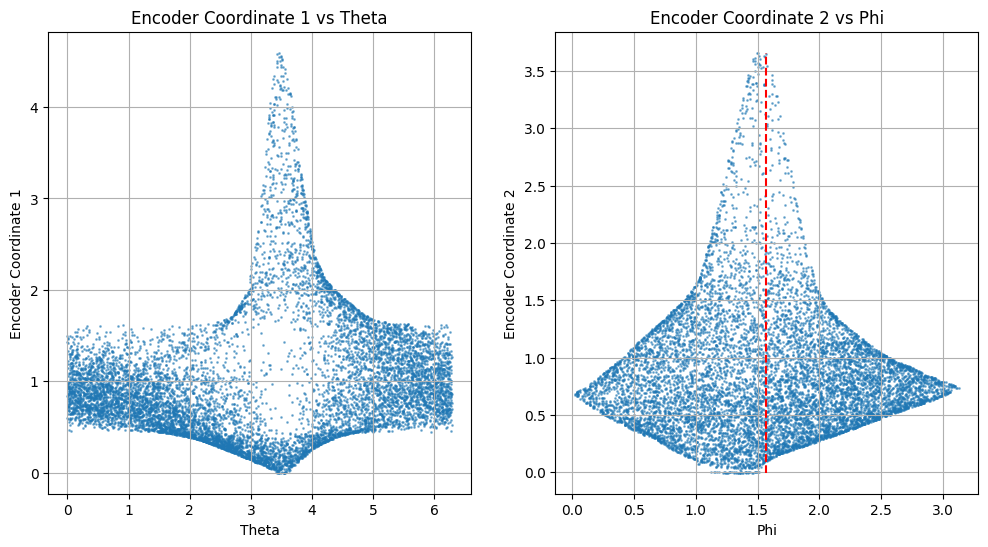

In [22]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Encoder Coordinate 1 vs Theta")
plt.xlabel("Theta")
plt.ylabel("Encoder Coordinate 1")
plt.scatter(X_angles[:, 1].cpu(), z_en[:, 0].cpu(), s=1, alpha=0.5) 
plt.grid()

plt.subplot(1, 2, 2)
plt.title("Encoder Coordinate 2 vs Phi")
plt.xlabel("Phi")
plt.ylabel("Encoder Coordinate 2")
plt.vlines(x=math.pi/2, ymin=z_en.cpu()[:, 1].min(), ymax=z_en.cpu()[:, 1].max(), color='r', linestyle='--', label='Equator (Theta=pi/2)')
plt.scatter(X_angles[:, 0].cpu(), z_en[:, 1].cpu(), s=1, alpha=0.5)
plt.grid()

# salvo i miei dati

In [69]:
import os
os.makedirs('data', exist_ok=True)
dataset_dict = {
    'angles': X_angles,
    'cartesian': Y_cartesian
}

angles_dict = {
    'encoder_coordinates': z_en,
    'angles': X_angles
}

file_path = os.path.join('data', 'sphere_dataset.pt')
torch.save(dataset_dict, file_path)
torch.save(angles_dict, os.path.join('data', 'encoder_angles.pt'))

print(f"Data successfully saved to {file_path}")

Data successfully saved to data\sphere_dataset.pt


In [70]:
#Loading the data back into PyTorch
loaded_data = torch.load('data/sphere_dataset.pt')

X_angles_loaded = loaded_data['angles']
Y_cartesian_loaded = loaded_data['cartesian']

In [71]:
loaded_model = Autoencoder(in_dim, hidden_dim, out_dim).to(device)
# Load the state_dict of our saved model (this will update the new instance of our model with trained weights)
loaded_model.load_state_dict(torch.load(f='models/Sphere_autoencoder.pth'))

<All keys matched successfully>

# sono stereografiche?

In [72]:
def coord_stereografiche(x):
    # x è un tensore di forma (N, 3) con coordinate cartesiane (x, y, z)
    x_cart = x[:, 0]
    y_cart = x[:, 1]
    z_cart = x[:, 2]
  
    denominator = 1 - z_cart + 1.e-10
    u = x_cart / denominator
    v = y_cart / denominator
    
    return torch.stack((u, v), dim=1)

In [73]:
class StereographicProjection(nn.Module):
    def __init__(self):
        super().__init__() 
        self.rotation = nn.Linear(3, 3, bias=False)  #rotazione 3D, bias=False perché no traslazioni!!
        self.lin_corr = nn.Linear(2, 2)  #regressione lineare per vedere se è stereografica!!!
        torch.transpose(self.rotation.weight, 0, 1) == torch.inverse(self.rotation.weight + 1.e-10*torch.eye(3)) #inizializzo la matrice di rotazione come matrice di identità (o quasi, per evitare problemi di inversione)

    def forward(self, x):
        rotated = self.rotation(x)
        projected = coord_stereografiche(rotated)
        z_hopefully = self.lin_corr(projected)
        return z_hopefully
    
stereo_model = StereographicProjection().to(device)

In [74]:
with torch.no_grad():
    z = model_1.encoder(Y_cartesian.to(device)).detach()

y_stereo = coord_stereografiche(Y_cartesian)

In [75]:
dataset_1 = torch.utils.data.TensorDataset(Y_cartesian, z)
train_dataset_1, test_dataset_1 = torch.utils.data.random_split(dataset_1, [int(0.8 * len(dataset_1)), int(0.2 * len(dataset_1))])
train_loader_1 = torch.utils.data.DataLoader(train_dataset_1, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader_1 = torch.utils.data.DataLoader(test_dataset_1, batch_size=len(test_dataset_1), shuffle=False, drop_last=True)

In [76]:
loss_fn = nn.MSELoss()
optimizer_0 = optim.Adam(stereo_model.parameters(), lr=1e-3, weight_decay=1e-6)

In [77]:
epochs = 40

train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    sum_loss = 0.0
    for x, y in train_loader_1:
        x = x.to(device)
        y = y.to(device)
        stereo_model.train()
        y_pred = stereo_model(x)
        loss = loss_fn(y_pred, y)
        sum_loss += loss.item()
        optimizer_0.zero_grad()
        loss.backward()
        optimizer_0.step()

    avg_loss = sum_loss / len(train_loader_1)
    with torch.no_grad(): 
      stereo_model.eval()
      for x, y in test_loader_1:
        test_features = x.to(device)
        test_labels = y.to(device)
      test_pred = stereo_model(test_features)
      test_loss = loss_fn(test_pred, test_labels)
      epoch_count.append(epoch)
      train_loss_values.append(avg_loss)
      test_loss_values.append(test_loss.detach().cpu().numpy())
      if (epoch) % 5 == 0:
         print(f"Epoch: {epoch} | MSE Train Loss: {avg_loss} | MSE Test Loss: {test_loss} ")

Epoch: 0 | MSE Train Loss: 0.24052156507968903 | MSE Test Loss: 0.21162718534469604 
Epoch: 5 | MSE Train Loss: 0.06781955473124981 | MSE Test Loss: 0.060644324868917465 
Epoch: 10 | MSE Train Loss: 0.0149274957831949 | MSE Test Loss: 0.015585034154355526 
Epoch: 15 | MSE Train Loss: 0.004642836055427324 | MSE Test Loss: 0.005886933766305447 
Epoch: 20 | MSE Train Loss: 0.004623362657730468 | MSE Test Loss: 0.005703787785023451 
Epoch: 25 | MSE Train Loss: 0.004619890474714339 | MSE Test Loss: 0.005726405885070562 
Epoch: 30 | MSE Train Loss: 0.00461593365034787 | MSE Test Loss: 0.005745314992964268 
Epoch: 35 | MSE Train Loss: 0.004614256680360996 | MSE Test Loss: 0.0057683526538312435 


In [78]:
y_rotated = stereo_model.rotation(Y_cartesian.to(device)).detach()
y_stereo = coord_stereografiche(y_rotated.to(device))

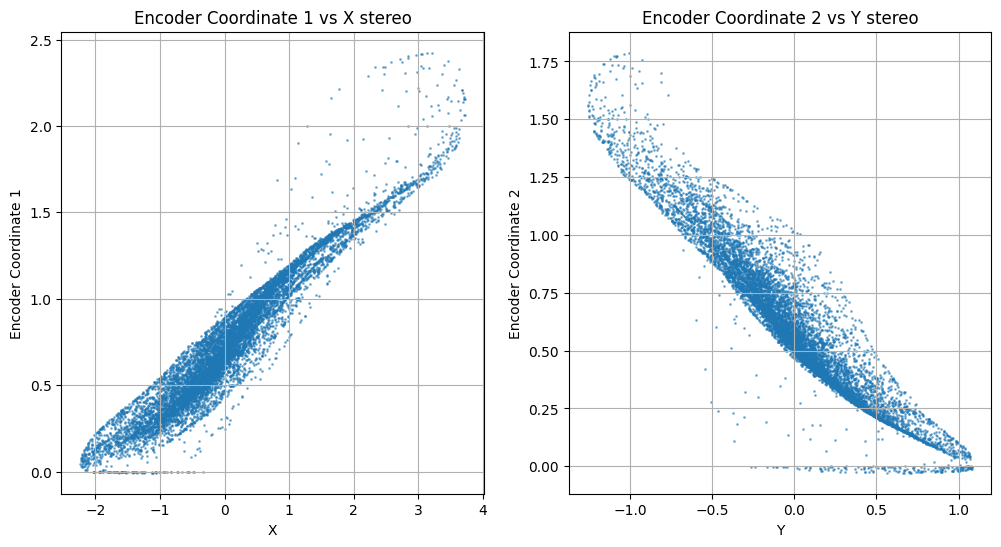

In [81]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Encoder Coordinate 1 vs X stereo")
plt.xlabel("X")
plt.ylabel("Encoder Coordinate 1")
plt.scatter(y_stereo[:, 1].cpu(), z[:, 1].cpu(), s=1, alpha=0.5) 
plt.grid()

plt.subplot(1, 2, 2)
plt.title("Encoder Coordinate 2 vs Y stereo")
plt.xlabel("Y")
plt.ylabel("Encoder Coordinate 2")
plt.scatter(y_stereo[:, 0].cpu(), z[:, 0].cpu(), s=1, alpha=0.5)
plt.grid()

In [83]:
X_stereo = torch.stack((y_stereo[:, 1], z[:, 1]), dim=1)
Y_stereo = torch.stack((y_stereo[:, 0], z[:, 0]), dim=1)
R_x = torch.corrcoef(X_stereo.T.cpu())
R_y = torch.corrcoef(Y_stereo.T.cpu())
print("Correlation between Encoder Coordinate 1 and X stereo:", R_x[0, 1].item())
print("Correlation between Encoder Coordinate 2 and Y stereo:", R_y[0, 1].item())

Correlation between Encoder Coordinate 1 and X stereo: 0.9569987654685974
Correlation between Encoder Coordinate 2 and Y stereo: -0.9442253708839417


In [84]:
def stereo_inv(z):
    u = z[:, 0]
    v = z[:, 1]
    denominator = 1 + u**2 + v**2
    x = 2 * u / denominator
    y = 2 * v / denominator
    z_cart = (denominator - 2) / denominator
    return torch.stack((x, y, z_cart), dim=1)

In [85]:
model_1.eval()
encoder = model_1.encoder
decoder = model_1.decoder

# 2. Calcoliamo i confini effettivi dello spazio latente per sapere dove creare la griglia
with torch.no_grad():
    latents = encoder(Y_cartesian.to(device)).cpu().numpy()

z1_min, z1_max = latents[:, 0].min(), latents[:, 0].max()
z2_min, z2_max = latents[:, 1].min(), latents[:, 1].max()

# 3. Definiamo la densità della griglia (quanti "assi" vogliamo)
num_lines = 15       # Numero di linee per ogni asse coordinato
pts_per_line = 100   # Risoluzione di ogni linea per renderla fluida nel 3D

z1_values = np.linspace(z1_min, z1_max, num_lines)
z2_values = np.linspace(z2_min, z2_max, num_lines)

# 4. Inizializziamo la figura Plotly
fig = go.Figure()

# Nota: Mettiamo i punti originali grigi e trasparenti sullo sfondo per dare un riferimento visivo
x_orig = Y_cartesian[:, 0].cpu().numpy()
y_orig = Y_cartesian[:, 1].cpu().numpy()
z_orig = Y_cartesian[:, 2].cpu().numpy()

fig.add_trace(go.Scatter3d(
    x=x_orig, y=y_orig, z=z_orig,
    mode='markers',
    marker=dict(size=1.5, color='lightgray', opacity=0.15),
    name='Sfera di Riferimento'
))

# 5. Generiamo e decodifichiamo le linee degli assi latenti
with torch.no_grad():
    
    # --- ASSE 1: Linee a Z1 costante (varia Z2) -> Colore BLU ---
    for z1 in z1_values:
        line_2d = np.zeros((pts_per_line, 2))
        line_2d[:, 0] = z1
        line_2d[:, 1] = np.linspace(z2_min, z2_max, pts_per_line)
        
        # Passiamo la linea al decoder
        line_tensor = torch.tensor(line_2d, dtype=torch.float32).to(device)
        xyz = decoder(line_tensor).cpu().numpy()
        
        fig.add_trace(go.Scatter3d(
            x=xyz[:, 0], y=xyz[:, 1], z=xyz[:, 2],
            mode='lines',
            line=dict(color='rgba(0, 0, 255, 0.7)', width=2.5),
            showlegend=False
        ))

    # --- ASSE 2: Linee a Z2 costante (varia Z1) -> Colore ROSSO ---
    for z2 in z2_values:
        line_2d = np.zeros((pts_per_line, 2))
        line_2d[:, 0] = np.linspace(z1_min, z1_max, pts_per_line)
        line_2d[:, 1] = z2
        
        # Passiamo la linea al decoder
        line_tensor = torch.tensor(line_2d, dtype=torch.float32).to(device)
        xyz = decoder(line_tensor).cpu().numpy()
        
        fig.add_trace(go.Scatter3d(
            x=xyz[:, 0], y=xyz[:, 1], z=xyz[:, 2],
            mode='lines',
            line=dict(color='rgba(255, 0, 0, 0.7)', width=2.5), 
            showlegend=False
        ))

#griglia delle coordinate stereografiche--------------------------------------------------
with torch.no_grad():
    
    # --- ASSE 1: Linee a Z1 costante (varia Z2) -> Colore BLU ---
    for z1 in z1_values:
        line_2d = np.zeros((pts_per_line, 2))
        line_2d[:, 0] = z1
        line_2d[:, 1] = np.linspace(z2_min, z2_max, pts_per_line)
        
        # Passiamo la linea al decoder
        line_tensor = torch.tensor(line_2d, dtype=torch.float32).to(device)
        xyz = stereo_model.rotation(stereo_inv(line_tensor)).cpu().numpy()
        
        fig.add_trace(go.Scatter3d(
            x=xyz[:, 0], y=xyz[:, 1], z=xyz[:, 2],
            mode='lines',
            line=dict(color='green', width=2.5),
            showlegend=False
        ))

    # --- ASSE 2: Linee a Z2 costante (varia Z1) -> Colore ROSSO ---
    for z2 in z2_values:
        line_2d = np.zeros((pts_per_line, 2))
        line_2d[:, 0] = np.linspace(z1_min, z1_max, pts_per_line)
        line_2d[:, 1] = z2
        
        # Passiamo la linea al decoder
        line_tensor = torch.tensor(line_2d, dtype=torch.float32).to(device)
        xyz = stereo_model.rotation(stereo_inv(line_tensor)).cpu().numpy()
        
        fig.add_trace(go.Scatter3d(
            x=xyz[:, 0], y=xyz[:, 1], z=xyz[:, 2],
            mode='lines',
            line=dict(color='orange', width=2.5), 
            showlegend=False
        ))
#-----------------------------------------------------------------------------------------------
# 6. Configurazione finale del Layout per visualizzare una sfera perfetta
fig.update_layout(
    title="Assi di Coordinata dell'Autoencoder deformati sulla Sfera 3D",
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        aspectmode='cube' # Fondamentale per non distorcere la sfera in un uovo
    ),
    margin=dict(l=0, r=0, b=0, t=50)
)

fig.show()

# model 2

In [64]:
in_dim = 3
out_dim = 2
inner_dim = 100
#idea per ora: gli hidden layer li faccio con la stessa dim dell'output
#forse così impara una f.ne non lineare di 2 variabili(vediamo)
encoder = nn.Sequential(
  nn.Linear(in_dim, inner_dim), #0
  nn.Tanh(),
  nn.Linear(inner_dim, inner_dim), #1
  nn.Tanh(),
  nn.Linear(inner_dim, inner_dim), #2
  nn.Tanh(),
  nn.Linear(inner_dim, out_dim), #3

  
)
#domanda nellìarchitettura, ma ha senso mettere alla fine una Tanh?

decoder = nn.Sequential(
  nn.Linear(out_dim, inner_dim), #0
  nn.Tanh(),
  nn.Linear(inner_dim, inner_dim), #1
  nn.Tanh(),
  nn.Linear(inner_dim, inner_dim), #2
  nn.Tanh(),
  nn.Linear(inner_dim, inner_dim), #3
  nn.Tanh(),
  nn.Linear(inner_dim, in_dim), #4
)

model_2 = nn.Sequential(
    encoder,
    decoder,
)

model_2 = model_2.to(device)

In [65]:
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model_1.parameters(), lr=1e-2, weight_decay=1e-6)

In [66]:
num_epochs = 5
model_2.train()
for epoch in range(num_epochs):

    loss_epoch = 0.0

    for x, _ in train_loader:

        x = x.to(device) #in teoria le y non servono no?

        x_pred = model_2(x)
        loss = loss_fn(x_pred, x)
        #train 
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_epoch += loss.item() #item() per prendere il valore scalare dal tensore

    print(f"Epoch {epoch + 1}, Loss: {loss_epoch / len(train_loader):.5f}")


Epoch 1, Loss: 0.33217
Epoch 2, Loss: 0.33217
Epoch 3, Loss: 0.33217
Epoch 4, Loss: 0.33217
Epoch 5, Loss: 0.33217


When training autoencoders, often it best to see the result of reconstruction instead of focusing only on the numerical loss of the model

**Exercise 1**: Define the encoder and decoder modules for our autoencoder. Can we improve its performance by **optimizing hyperparameters** and adjusting the model architecture? Additionally, can we include a **visualization of the train and test loss** over the training process to detect signs of overfitting?

In [ ]:
...